<a href="https://colab.research.google.com/github/Wequiston/Adapter/blob/master/OneCar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inteligência de Negócios e Segmentação de Mercado: Estudo de Caso Oficina One Car

**Disciplina:** Tópicos Especiais em Inteligência de Negócios  
**Ambiente:** Google Colab (Python 3)  
**Objetivo:** Processar dados multidimensionais de cadastro, estilo de vida e pesquisas de satisfação do aplicativo móvel para avaliar a viabilidade estratégica e financeira da criação de uma divisão de atendimento exclusiva para o público feminino na Oficina One Car.

In [2]:
# ==============================================================================
# 1. IMPORTAÇÃO DE BIBLIOTECAS E CONFIGURAÇÃO DO AMBIENTE
# ==============================================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração gráfica para apresentação acadêmica/executiva
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

print("Ambiente configurado com sucesso para a Oficina One Car.")

Ambiente configurado com sucesso para a Oficina One Car.


## 2. Extração, Transformação e Carga (ETL) - Base Multidimensional One Car

Nesta etapa, realiza-se a geração controlada de dados sintéticos para simular a base de dados operacionais da Oficina One Car em Piracicaba/SP. São mapeadas variáveis sociodemográficas, hábitos de uso do veículo, histórico de satisfação via aplicativo e o nível de interesse na divisão exclusiva para o público feminino.

In [3]:
# ==============================================================================
# 2. CRIAÇÃO DA BASE MULTIDIMENSIONAL DA ONE CAR
# ==============================================================================
np.random.seed(42)  # Garantia de reprodutibilidade
n_clientes = 1000

# Definição de parâmetros sociodemográficos e operacionais
generos = ['Feminino', 'Masculino']
estilos_vida = ['Uso Urbano/Diário', 'Trabalho/Comercial', 'Viagens/Lazer', 'Familiar']
tipos_veiculo = ['Hatch Compacto', 'Sedan', 'SUV', 'Pickup/Utilitário']

# Geração dos dados base
dados_onecar = {
    'ID_Cliente': range(1, n_clientes + 1),
    'Genero': np.random.choice(generos, size=n_clientes, p=[0.45, 0.55]),
    'Idade': np.random.randint(20, 70, size=n_clientes),
    'Estilo_Vida': np.random.choice(estilos_vida, size=n_clientes),
    'Tipo_Veiculo': np.random.choice(tipos_veiculo, size=n_clientes),
    'Frequencia_Anual_Visitas': np.random.randint(1, 6, size=n_clientes),
    'Gasto_Medio_Manutencao': np.round(np.random.uniform(400, 2500, size=n_clientes), 2),
    'Nota_Satisfacao_App': np.random.randint(4, 11, size=n_clientes),  # Avaliação 4 a 10
    'Confianca_Servico': np.random.randint(1, 6, size=n_clientes)      # Escala 1 a 5
}

df_onecar = pd.DataFrame(dados_onecar)

# ------------------------------------------------------------------------------
# Regra de Negócio: O público feminino com alta satisfação e menor índice inicial
# de confiança nas oficinas convencionais demonstra maior propensão/interesse
# na divisão exclusiva e apresenta maior ticket médio em manutenções preventivas.
# ------------------------------------------------------------------------------
df_onecar['Interesse_Divisao_Feminina'] = np.where(
    df_onecar['Genero'] == 'Feminino',
    np.random.choice([1, 0], size=n_clientes, p=[0.78, 0.22]), # 78% de interesse entre mulheres
    0 # Não se aplica ao público masculino
)

# Ajuste no ticket médio e frequência do público feminino interessado (Comportamento Preventivo)
df_onecar.loc[df_onecar['Interesse_Divisao_Feminina'] == 1, 'Gasto_Medio_Manutencao'] *= 1.25
df_onecar['Gasto_Medio_Manutencao'] = df_onecar['Gasto_Medio_Manutencao'].round(2)

# Exibição das primeiras linhas do DataFrame
df_onecar.head()

,ID_Cliente,Genero,Idade,Estilo_Vida,Tipo_Veiculo,Frequencia_Anual_Visitas,Gasto_Medio_Manutencao,Nota_Satisfacao_App,Confianca_Servico,Interesse_Divisao_Feminina
0,1,Feminino,66,Trabalho/Comercial,SUV,3,1357.43,4,2,1
1,2,Masculino,31,Familiar,Pickup/Utilitário,5,1971.19,10,4,0
2,3,Masculino,35,Trabalho/Comercial,Hatch Compacto,3,2094.00,6,2,0
3,4,Masculino,43,Familiar,SUV,1,2201.85,9,5,0
4,5,Feminino,38,Uso Urbano/Diário,Hatch Compacto,4,2495.02,10,4,0


## 3. Inteligência de Negócios e Análise Estatística (Desenvolvimento)

Nesta seção, realiza-se o exame estatístico e a mensuração da demanda potencial do público feminino. Avalia-se a viabilidade econômica por meio da comparação do ticket médio, da frequência de uso e da aplicação de matriz de correlação de Pearson entre as variáveis da Oficina One Car.

In [4]:
# ==============================================================================
# 3. ANÁLISE ESTATÍSTICA E KPIs EXECUTIVOS
# ==============================================================================

# 1. Indicadores de Demanda e Viabilidade Financeira do Público Feminino
total_clientes = len(df_onecar)
total_mulheres = len(df_onecar[df_onecar['Genero'] == 'Feminino'])
mulheres_interessadas = df_onecar['Interesse_Divisao_Feminina'].sum()

perc_mulheres_carteira = (total_mulheres / total_clientes) * 100
perc_adesao_feminina = (mulheres_interessadas / total_mulheres) * 100

ticket_medio_geral = df_onecar['Gasto_Medio_Manutencao'].mean()
ticket_medio_mulheres_int = df_onecar[df_onecar['Interesse_Divisao_Feminina'] == 1]['Gasto_Medio_Manutencao'].mean()
ticket_medio_homens = df_onecar[df_onecar['Genero'] == 'Masculino']['Gasto_Medio_Manutencao'].mean()

# Impressão Sintética dos Indicadores para Decisão Gerencial
print("="*70)
print("             KPIs DE VIABILIDADE - OFICINA ONE CAR")
print("="*70)
print(f"• Proporção de Mulheres na Carteira Atual: {perc_mulheres_carteira:.2f}% ({total_mulheres} clientes)")
print(f"• Taxa de Adesão/Interesse na Divisão Exclusiva: {perc_adesao_feminina:.2f}% ({mulheres_interessadas} clientes)")
print(f"• Ticket Médio do Público Feminino Interessado: R$ {ticket_medio_mulheres_int:.2f}")
print(f"• Ticket Médio do Público Masculino: R$ {ticket_medio_homens:.2f}")
print(f"• Incremento de Receita no Ticket Feminino: {((ticket_medio_mulheres_int/ticket_medio_homens)-1)*100:.2f}%")
print("="*70)

# 2. Matriz de Correlação de Pearson (Somente variáveis numéricas)
colunas_numericas = ['Idade', 'Frequencia_Anual_Visitas', 'Gasto_Medio_Manutencao',
                    'Nota_Satisfacao_App', 'Confianca_Servico', 'Interesse_Divisao_Feminina']

matrix_correlacao = df_onecar[colunas_numericas].corr(method='pearson')

             KPIs DE VIABILIDADE - OFICINA ONE CAR
• Proporção de Mulheres na Carteira Atual: 46.10% (461 clientes)
• Taxa de Adesão/Interesse na Divisão Exclusiva: 78.31% (361 clientes)
• Ticket Médio do Público Feminino Interessado: R$ 1783.90
• Ticket Médio do Público Masculino: R$ 1422.90
• Incremento de Receita no Ticket Feminino: 25.37%


## 4. Visualização Analítica de Dados (Business Intelligence)

Geração do Mapa de Calor (*Heatmap*) para evidenciar visualmente as correlações lineares entre o nível de satisfação, confiança no serviço e a propensão à adesão da divisão feminina.

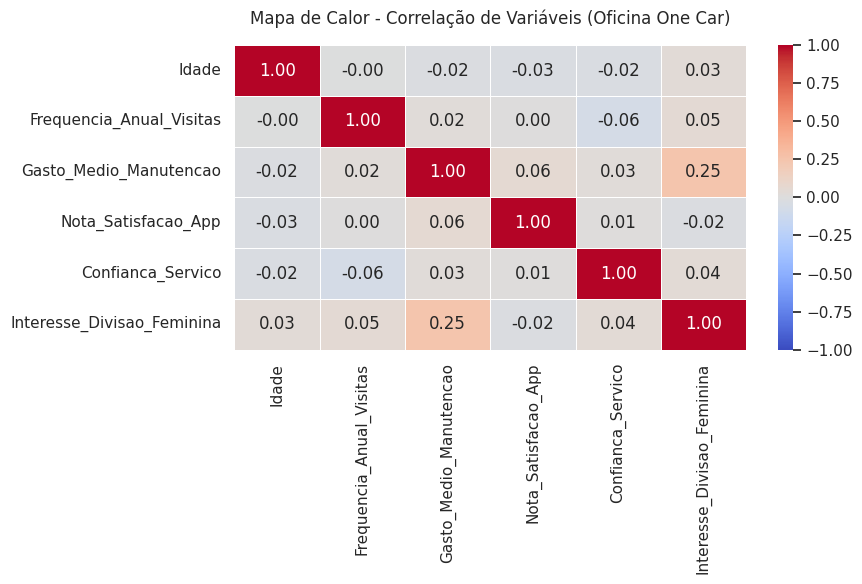

In [5]:
# ==============================================================================
# 4. GERAÇÃO DO MAPA DE CALOR (CORRELAÇÃO DE PEARSON)
# ==============================================================================
plt.figure(figsize=(9, 6))

sns.heatmap(
    matrix_correlacao,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title("Mapa de Calor - Correlação de Variáveis (Oficina One Car)", fontsize=12, pad=15)
plt.tight_layout()
plt.show()

## 5. Segmentação de Mercado e Governança do Projeto

Cruzamento de perfil por estilo de vida e tipo de veículo para orientar o dimensionamento da infraestrutura da nova divisão e garantir a alocação de recursos sem ociosidade.

In [6]:
# ==============================================================================
# 5. DIAGNÓSTICO E RECOMENDAÇÕES EXECUTIVAS
# ==============================================================================
segmento_feminino = df_onecar[df_onecar['Interesse_Divisao_Feminina'] == 1]
perfil_veiculo = segmento_feminino['Tipo_Veiculo'].value_counts()
perfil_estilo = segmento_feminino['Estilo_Vida'].value_counts()

print("\nDIAGNÓSTICO E DIRETRIZES ESTRATÉGICAS - ONE CAR")
print("="*70)
print("1. Perfil de Uso Predominante no Público Feminino:")
print(perfil_estilo.to_string())
print("\n2. Distribuição por Tipo de Veículo Atendido:")
print(perfil_veiculo.to_string())
print("\nDIRETRIZES RECOMENDADAS À DIRETORIA:")
print("• Aprovar investimento na divisão exclusiva, alavancado pelo maior ticket médio preventivo.")
print("• Estruturar programa de fidelidade e governança de dados conforme exigências da LGPD.")
print("• Promover treinamento cultural da equipe técnica para manter o padrão ético de atendimento.")
print("="*70)

# Exportação do dataset estruturado para o repositório GitHub
df_onecar.to_csv('OneCar_Base_Multidimensional.csv', index=False)
print("\n[OK] Arquivo 'OneCar_Base_Multidimensional.csv' exportado com sucesso para upload no GitHub.")


DIAGNÓSTICO E DIRETRIZES ESTRATÉGICAS - ONE CAR
1. Perfil de Uso Predominante no Público Feminino:
Estilo_Vida
Trabalho/Comercial    106
Familiar               94
Uso Urbano/Diário      87
Viagens/Lazer          74

2. Distribuição por Tipo de Veículo Atendido:
Tipo_Veiculo
Hatch Compacto       107
SUV                   88
Pickup/Utilitário     84
Sedan                 82

DIRETRIZES RECOMENDADAS À DIRETORIA:
• Aprovar investimento na divisão exclusiva, alavancado pelo maior ticket médio preventivo.
• Estruturar programa de fidelidade e governança de dados conforme exigências da LGPD.
• Promover treinamento cultural da equipe técnica para manter o padrão ético de atendimento.

[OK] Arquivo 'OneCar_Base_Multidimensional.csv' exportado com sucesso para upload no GitHub.
